In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#lets mount a drive since if I store files under /content in google colab drive, they delete after kernel refreshed
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#import data which is on /content/HW1_data

#hw tells you what medical attribute each column is. cols will just easily name the 6 med attrib, and pass into the pd.read_csv
cols = ['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle', 'sacral_slope', 'pelvic_radius', 'grade_of_spondylolisthesis', 'class']
#you can open the column_2C.dat file in notepad to see how its organized.
df = pd.read_csv('/content/drive/MyDrive/Grad_school/USC/EE559/HW1/column_2C.dat', sep = ' ', header =None, names = cols)

#turn classes into integer. 0 = normal 1 = abnormal
df['class'] = df['class'].map({'AB':1, 'NO':0})
df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,grade_of_spondylolisthesis,class
0,63.03,22.55,39.61,40.48,98.67,-0.25,1
1,39.06,10.06,25.02,29.00,114.41,4.56,1
2,68.83,22.22,50.09,46.61,105.99,-3.53,1
3,69.30,24.65,44.31,44.64,101.87,11.21,1
4,49.71,9.65,28.32,40.06,108.17,7.92,1


In [4]:
#inspect data using various python commands

df.shape # tells you shape of data. This is pesumably 310 patient data with 7 independent variables for each patient. Las columns is a class distinction,
#which means this patient was deemed to be NO (normal) or AB(abnormal) based on 6 med attributes

df.columns #tells you what each column name is and its data type (dtype)

df['class'].value_counts() #this looks at "class" and tells you what classses are there and how many of each class there is
#210 abnormal patients, 100 normal for a total of 310

df.describe()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,grade_of_spondylolisthesis,class
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496484,17.542903,51.930710,42.953871,117.920548,26.296742,0.677419
std,17.236109,10.008140,18.553766,13.422748,13.317629,37.558883,0.468220
min,26.150000,-6.550000,14.000000,13.370000,70.080000,-11.060000,0.000000
25%,46.432500,10.667500,37.000000,33.347500,110.710000,1.600000,0.000000
50%,58.690000,16.360000,49.565000,42.405000,118.265000,11.765000,1.000000
75%,72.880000,22.120000,63.000000,52.692500,125.467500,41.285000,1.000000
max,129.830000,49.430000,125.740000,121.430000,163.070000,418.540000,1.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

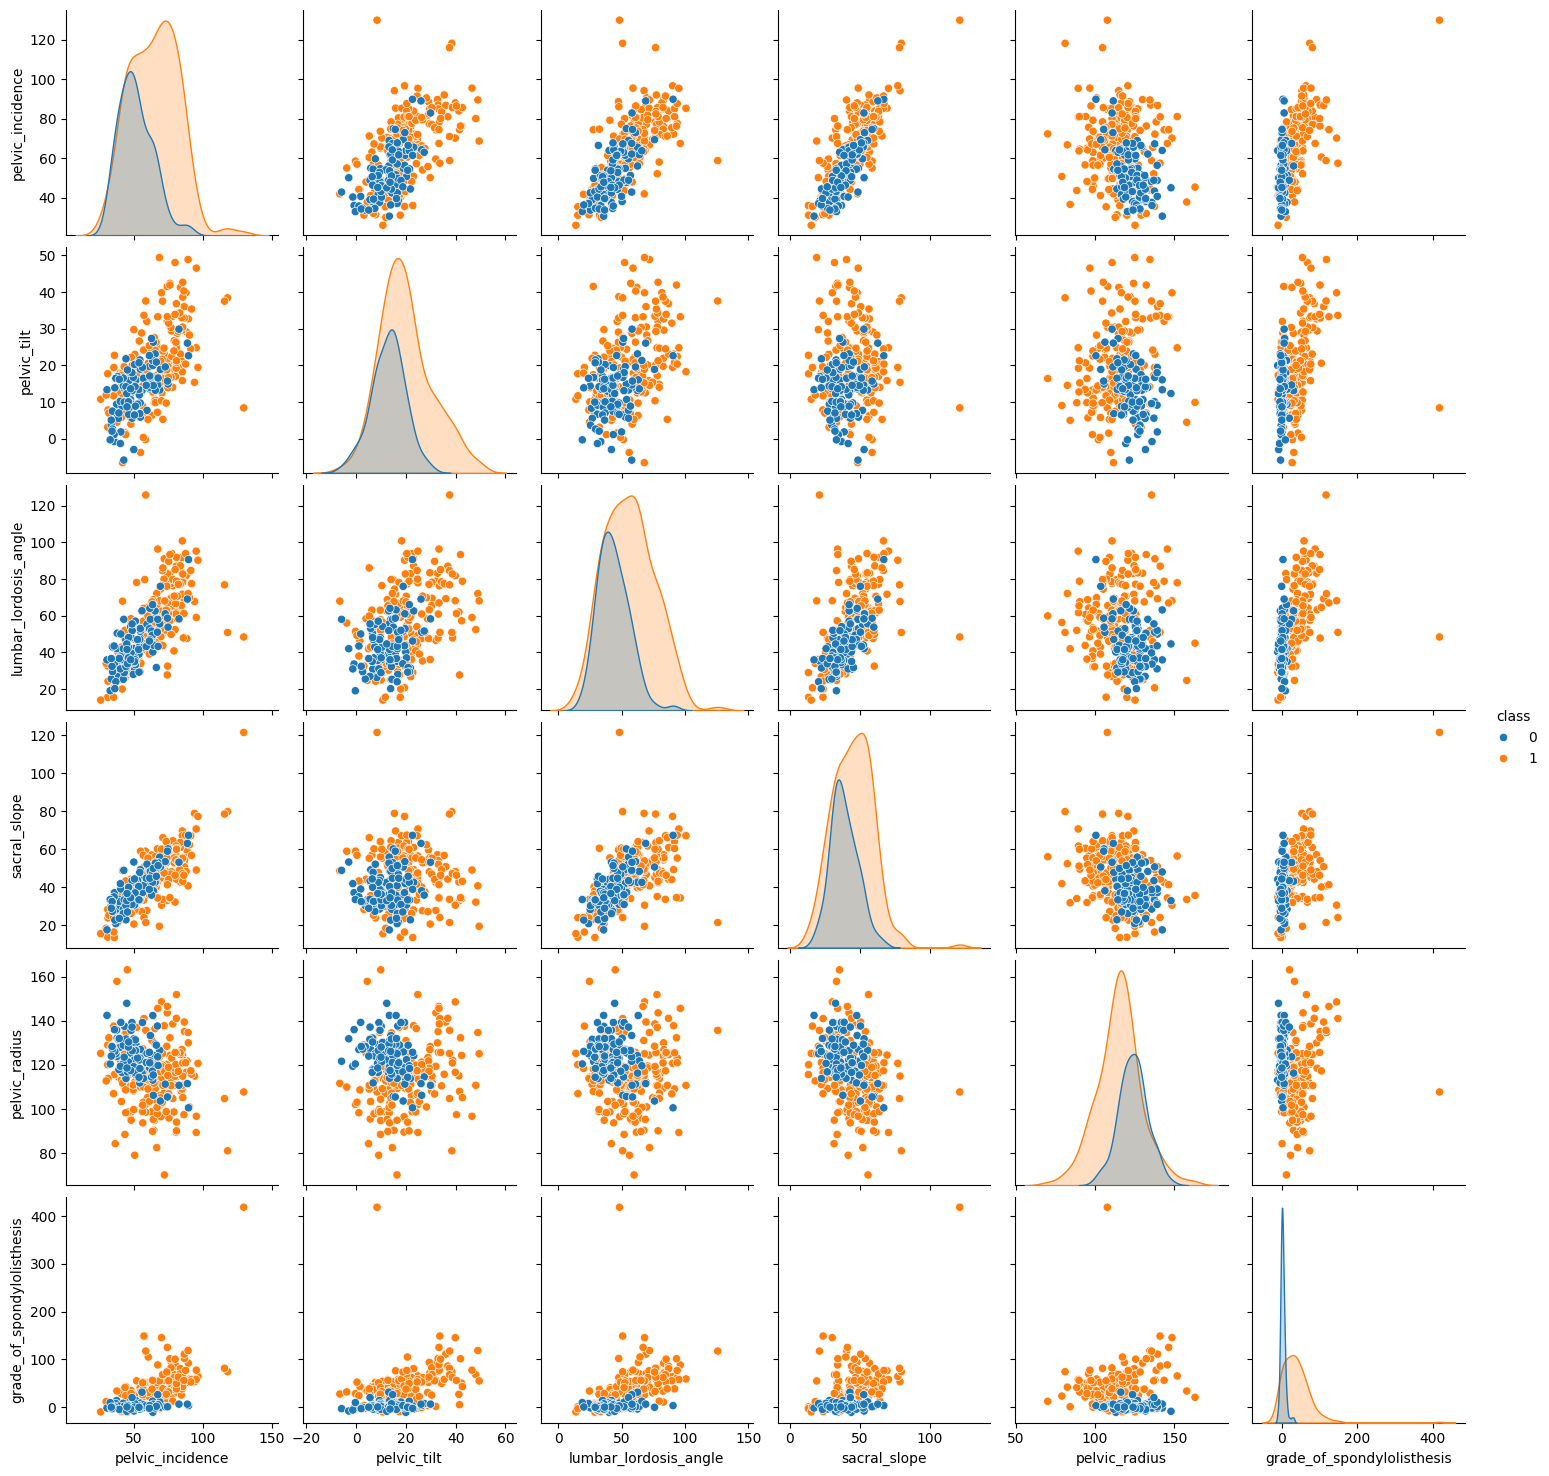

In [5]:
#(b) Pre-Processing and Exploratory data analysis:
#(i) make scatter plots


g = sns.pairplot(df, hue='class')

#download file
g.savefig('pairplot.png', dpi = 300, bbox_inches = 'tight')
from google.colab import files
files.download('pairplot.png')

plt.show()


**Comments on graph**

0 = blue = normal (NO)
1 = orange = abnormal (AB)

1. grade_of_spondylolisthesis shows strong separation between the two classes.
Normal patients are concentrated near small values, while abnormal patients
have a much larger spread and generally larger values. This feature may have
strong predictive power.

2. pelvic_incidence, lumbar_lordosis_angle, and sacral_slope show strong
positive correlation. As one feature increases, the others tend to increase
as well.

3. Many abnormal patients tend to have larger feature values than normal
patients, especially in pelvic_incidence, sacral_slope, and
grade_of_spondylolisthesis.

4. pelvic_radius shows substantial overlap between the two classes,
suggesting it may be a weaker predictor.

5. Some feature pairs appear to show partial clustering between the normal
and abnormal classes, although the classes are not perfectly separable.


#Turned to cell since I didnt run. Probably used to debug/understand code in the beginning.
for feature in features:
  print(feature)

print(features)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

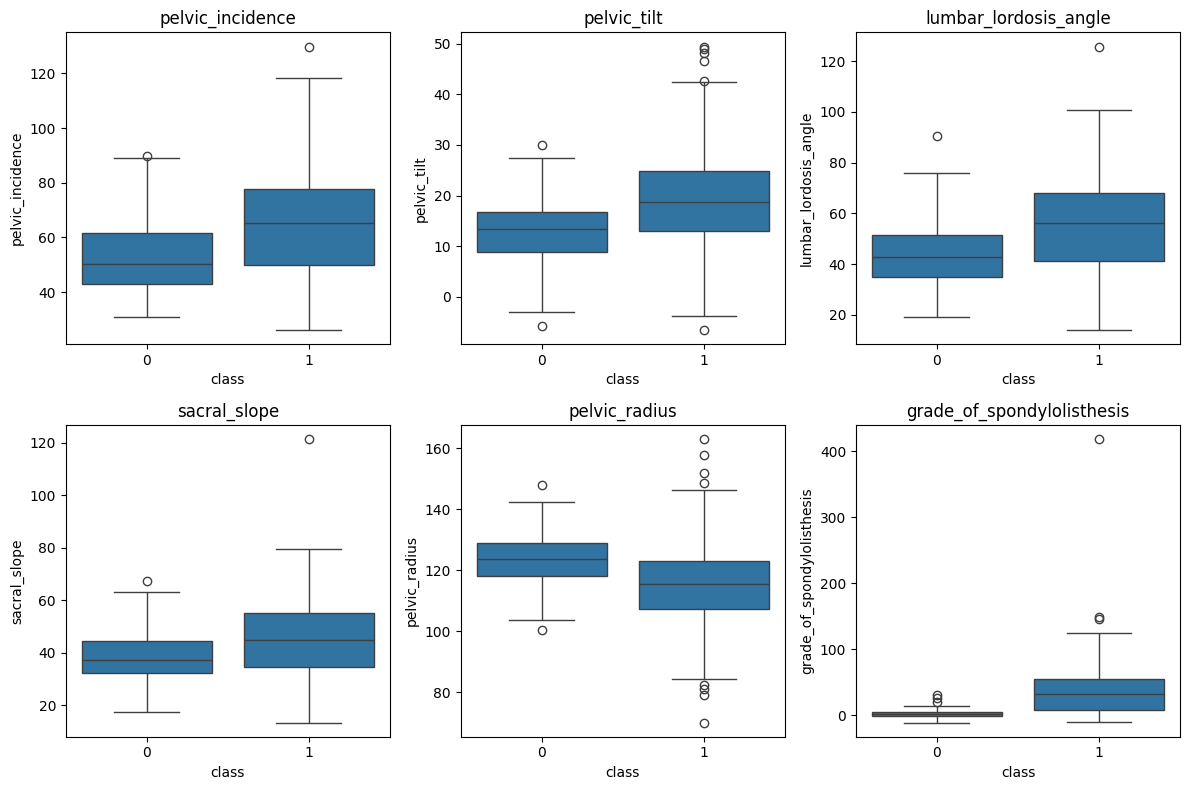

In [6]:
#(ii) boxplots for each independent variables

#extract features
features = df.columns[:-1] #[:-1] takes all columns except the last. class is not a feature, but rest of columns are features

#I want to save plots as a .png, so extra code is to accomodate this.
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='class', y=feature, ax = axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.savefig('boxplots.png', dpi = 300, bbox_inches = 'tight')
from google.colab import files
files.download('boxplots.png')
plt.show()





Remember, 0 = normal and 1 = abnormal


1.   bottom right plot (grade of spond) dont overlap, so this has strong discriminating power. Cleanest seperation between two classes for KNN.
2.   abnormal patients have larger mean exect for pelvic_radius.
3.   abnormal patients tend to have a larger spread comparted to normal
4.   pelvic_radius has mean and spread clsoer to normal patients, suggesting this will be harder to classify since both classes seem similar.
5.   there are some outliers, which KNN may be sensitive to



In [7]:
#(iii) Select the first 70 rows of Class 0 and the first 140 rows of Class 1 as the training set and the rest of the data as the test set.
#so basically we need to seperate the data into its classes, then take the 1st 70 rows of class 0 and 1st 140 rows of class1 and save them as training data. The rest is test data

#seperate data into classes
class0 = df[df['class'] == 0]
class1 = df[df['class'] == 1]

#seperate 1st 70 of class0 and 1st 140 of class1 and call it training
train0=class0.iloc[:70]
train1=class1.iloc[:140]

#seperate rest into testing data
test0 = class0.iloc[70:]
test1 = class1.iloc[140:]

#combine training and testing data using panda's concat
train = pd.concat([train0, train1])
test = pd.concat([test0, test1])

#now, need to seperate class from rest of data. This cause the actual features that will need to be trained using KNN is the data not the class. The class label is the answer. Need to split that up
#so we can use the medical attributes as features and use the AB or NO as the answer.

x_train = train.drop('class', axis=1) #this makes x_train the same was train, but drops the 'class' column
y_train = train['class']              #this makes y_train only the 'class' column

x_test = test.drop('class', axis=1) #this makes x_test the same was test, but drops the 'class' column
y_test = test['class']              #this makes y_test only the 'class' column


#verify datasizes match
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(210, 6)
(210,)
(100, 6)
(100,)


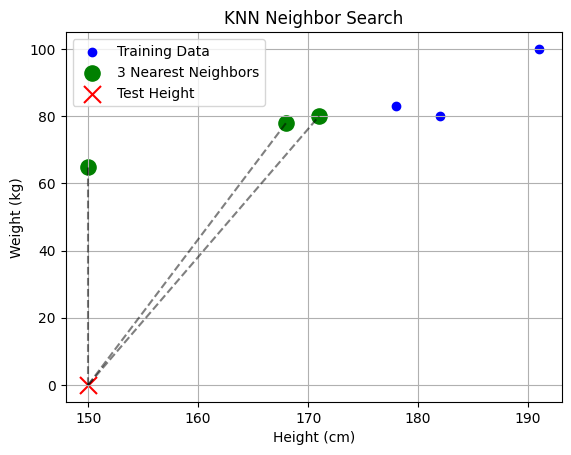

In [8]:
#visualization for HW1 KNN calculation.
# training data
heights = np.array([171, 168, 191, 182, 150, 178])
weights = np.array([80, 78, 100, 80, 65, 83])

# test height
x_test_HW = 150

# compute distances
distances = np.abs(heights - x_test_HW)

# find indices of 3 nearest neighbors
neighbors = np.argsort(distances)[:3]

# plot all training points
plt.scatter(
    heights,
    weights,
    color='blue',
    label='Training Data'
)

# highlight nearest neighbors
plt.scatter(
    heights[neighbors],
    weights[neighbors],
    color='green',
    s=120,
    label='3 Nearest Neighbors'
)

# plot test point at y=0
plt.scatter(
    x_test_HW,
    0,
    color='red',
    s=150,
    marker='x',
    label='Test Height'
)

# draw horizontal distance lines
for idx in neighbors:
    plt.plot(
        [x_test_HW, heights[idx]],
        [0, weights[idx]],
        'k--',
        alpha=0.5
    )

plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('KNN Neighbor Search')

plt.legend()
plt.grid(True)

plt.show()

In [9]:
print(x_test)

     pelvic_incidence  pelvic_tilt  lumbar_lordosis_angle  sacral_slope  \
280             50.09        13.43                  34.46         36.66   
281             64.26        14.50                  43.90         49.76   
282             53.68        13.45                  41.58         40.24   
283             49.00        13.11                  51.87         35.88   
284             59.17        14.56                  43.20         44.60   
..                ...          ...                    ...           ...   
205             80.11        33.94                  85.10         46.17   
206             95.48        46.55                  59.00         48.93   
207             74.09        18.82                  76.03         55.27   
208             87.68        20.37                  93.82         67.31   
209             48.26        16.42                  36.33         31.84   

     pelvic_radius  grade_of_spondylolisthesis  
280         119.13                        3.09  
2

In [10]:
#Classification using KNN on Vertebral Column Data Set (20 pts)
#i. Write code for k-nearest neighbors with Euclidean metric (or use a softwarepackage).
#ii. Test all the data in the test database with k nearest neighbors. Take decisions by majority polling. Plot train and test errors in terms of k for
#k ∈ {208, 205, . . . , 7, 4, 1, } (in reverse order). You are welcome to use smaller
#increments of k. Which k* is the most suitable k among those values? Calculate the confusion matrix, true positive rate, true negative rate, precision,
#and F1-score when k = k*.



#lets use a package
from sklearn.neighbors import KNeighborsClassifier

#
k = 3 #start with 3 NN

#initialize function as knn and use k=k neighbors. This creates the KNN model.
knn = KNeighborsClassifier(n_neighbors=k)
#train the model. This is taking x_train, which is the 6 medical attributes and its data for the 210 patients. y_train is the "answer" which is "is this patient normal or abnormal?"
# for each tet point in x_test, KNN computes eucledian distnace btween a point x_test and all other points in x_train (like in HW1 prob 1). The closest k=3 NN is chosen. After it takes the 3 closest neighbors,
# those points in x_train that are closest to x_test are either normal (0) or abnormal (1). y_train is used to look up the answer and store as a predction. A majority vote is used (so if 3 NN are found out to be
# [1 1 0], then predict 1 (abnormal)) to decide prediction. So the mdoel uses x_train and y_train to store the points of a sample population, and the answer to 0 or 1.
knn.fit(x_train, y_train)
#what knn.predict does is now take each point in x_test (100 pts), find its k=3 NN in x_train (210 pts), then says, the 3 NN are patiens a, b, c. Then it uses y_train to say, a is a normal, b is abnormal,...
#after that, y_pred is the majority vote output of those patients.
y_pred = knn.predict(x_test)



In [11]:
#now that we have a gist of what we are doing, HW wants us to use k=208, plot train and test error, then do k=205, plot train and test error, and do this until k=1 and find best k=k*

#create k vals starting at k=208 and decriment by 3 until k=1. This is per HW assignment.
k_vals = np.arange(208, 0, -1)

#initalize output variables
test_errors = []
train_errors = []

#initalize model and loop through k
for k in k_vals:
  #model
  #initalize model
  knn = KNeighborsClassifier(n_neighbors=k)
  #train model on training data
  knn.fit(x_train, y_train)

  #get training data accuracy. To do this, input training data
  y_train_pred = knn.predict(x_train)
  #get testing data accuracy. To do this, input testing data
  y_test_pred = knn.predict(x_test)

  #calculate errors. Since prediction output is something like [0 1 1 0 ..], and the real answer has a similar output, to get accuracy, we want to see if prediction of 0 matches training data of 0. If it does then
  #answer is correct. If not, answer is false. You can use a logical comparison for this, then take the mean of the output of the logical comparison to get accuracy

  #get training accuracy
  acc_train = (y_train_pred == y_train).mean()
  train_errors.append(1 - acc_train)
  #get testing accuracy
  acc_test = (y_test_pred == y_test).mean()
  test_errors.append(1 - acc_test)





In [12]:
#plot results and deduce best k
print(np.size(train_errors))
print(np.size(test_errors))
print(k_vals)
#70 k_vals, so 70 accuracy measurements. want LOWEST error, so smallest error at some k=k*

#to get lets get min and max k
min_train_error = np.min(train_errors)
k_min_train_idx = np.where(train_errors == min_train_error)[0][0]
k_min_train = k_vals[k_min_train_idx]


min_test_error = np.min(test_errors)
k_min_test_idx = np.where(test_errors == min_test_error)[0][0]
k_min_test = k_vals[k_min_test_idx]

print('k val with least training error: ',k_min_train, '\n')
print('k val with least testing error: ',k_min_test, '\n')

208
208
[208 207 206 205 204 203 202 201 200 199 198 197 196 195 194 193 192 191
 190 189 188 187 186 185 184 183 182 181 180 179 178 177 176 175 174 173
 172 171 170 169 168 167 166 165 164 163 162 161 160 159 158 157 156 155
 154 153 152 151 150 149 148 147 146 145 144 143 142 141 140 139 138 137
 136 135 134 133 132 131 130 129 128 127 126 125 124 123 122 121 120 119
 118 117 116 115 114 113 112 111 110 109 108 107 106 105 104 103 102 101
 100  99  98  97  96  95  94  93  92  91  90  89  88  87  86  85  84  83
  82  81  80  79  78  77  76  75  74  73  72  71  70  69  68  67  66  65
  64  63  62  61  60  59  58  57  56  55  54  53  52  51  50  49  48  47
  46  45  44  43  42  41  40  39  38  37  36  35  34  33  32  31  30  29
  28  27  26  25  24  23  22  21  20  19  18  17  16  15  14  13  12  11
  10   9   8   7   6   5   4   3   2   1]
k val with least training error:  1 

k val with least testing error:  4 



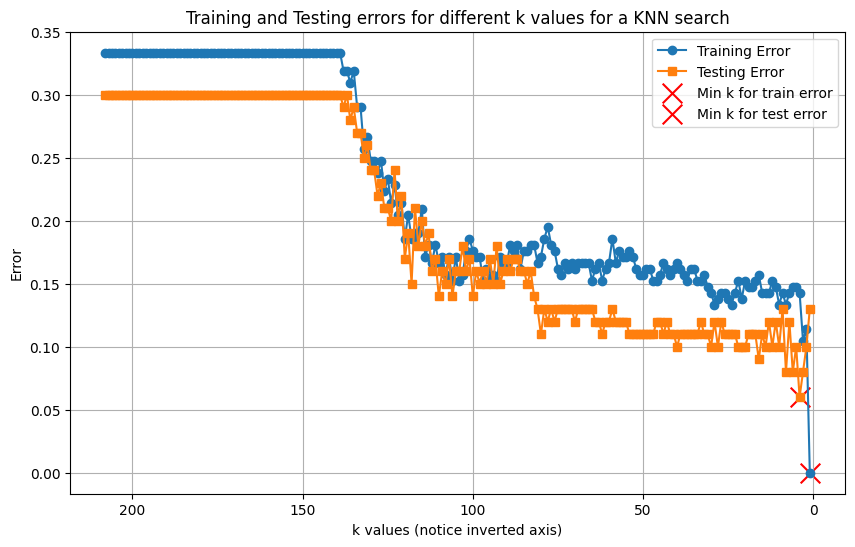

In [13]:
#plot results
plt.figure(figsize=(10, 6))
plt.plot(k_vals, train_errors, marker = 'o', label = 'Training Error')
plt.plot(k_vals, test_errors, marker = 's', label = 'Testing Error')
plt.scatter(k_min_train, train_errors[k_min_train_idx], marker = 'x', color = 'red', s=200, label = 'Min k for train error')
plt.scatter(k_min_test, test_errors[k_min_test_idx], marker = 'x', color = 'red', s=200, label = 'Min k for test error')
plt.xlabel('k values (notice inverted axis)')
plt.ylabel('Error')
plt.title('Training and Testing errors for different k values for a KNN search')
plt.grid(True)
plt.legend()
plt.gca().invert_xaxis()
plt.show()

**Comments on plot**


1.   train error is at k=1, which makes sense its its just memorizing data. Its basically a lookup table, so accuracy should be 100 percent, or 0 error. We have $k^*_{train} = 1$
2.   test error is at k=4. So finding the 4 NN yields the best results. We have $k^*_{test} = 4$
3.   after changing from incriments of 3 to incriments of 1, still get same results

Lets now use $k^*$ values to confusion matrix, true positive (tp), true negative (tn), precision, and F1 scores for $k=k^*$

To calc True Positive rate (TPR) we need:
$$TPR = \frac{TP}{TP+FN}$$
To calc True Negative rate (TNR) we need:
$$TNR = \frac{TN}{TN+FP}$$
To calculate Precision, we need:
$$\text{Precision} = \frac{TP}{TP+FP}$$
To calculate Recall, we need:
$$\text{Recall} = \frac{TP}{TP+FN}$$
To calc F1 score we use:
$$F1 = \frac{2\cdot \text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}$$



In [14]:
#initalize k stars
k_train = k_vals[k_min_train_idx] # k = 1 here
k_test = k_vals[k_min_test_idx]   # k= 4 here

print(k_train)
print(k_test)

#flow for training:

#recreate KNN model using k_star
knn = KNeighborsClassifier(n_neighbors=k_train)
knn.fit(x_train, y_train)
y_pred_train_k_star = knn.predict(x_train)
#calc confusion matrix using sklearn
from sklearn.metrics import confusion_matrix
cm_train = confusion_matrix(y_train, y_pred_train_k_star)
print(cm_train)

#confusion matrix has the TN, FP, FN, TP already in its entires. use the .ravel()to get them.
tn_train, fp_train, fn_train, tp_train = cm_train.ravel()
print(tn_train, fp_train, fn_train, tp_train)

#calculate metrics
tpr_train = tp_train / (tp_train + fn_train)
tnr_train = tn_train / (tn_train + fp_train)
precision_train = tp_train / (tp_train + fp_train)
recall_train = tp_train / (tp_train + fn_train)
f1_train = 2 * precision_train * recall_train / (precision_train + recall_train)




#flow for testing data

knn = KNeighborsClassifier(n_neighbors=k_test)
knn.fit(x_train, y_train)
y_pred_test_k_star = knn.predict(x_test)

cm_test = confusion_matrix(y_test, y_pred_test_k_star)
print(cm_test)
tn_test,fp_test,fn_test,tp_test = cm_test.ravel()
print(tn_test, fp_test, fn_test, tp_test)

tpr_test = tp_test / (tp_test + fn_test)
tnr_test = tn_test / (tn_test + fp_test)
precision_test = tp_test / (tp_test + fp_test)
recall_test = tp_test / (tp_test + fn_test)
f1_test = 2 * precision_test * recall_test / (precision_test + recall_test)

#create a neat table of data

results = {'Metric': ['TPR', 'TNR', 'Precision', 'Recall', 'F1'],
           'Training Data (k*=1)': [tpr_train, tnr_train, precision_train, recall_train,f1_train],
           'Testing Data (k*=4)': [tpr_test, tnr_test,precision_test,recall_test, f1_test]}

results_table = pd.DataFrame(results)
#set to 3 decimal places
results_table = results_table.round(3)
results_table

1
4
[[ 70   0]
 [  0 140]]
70 0 0 140
[[25  5]
 [ 1 69]]
25 5 1 69


,Metric,Training Data (k*=1),Testing Data (k*=4)
0,TPR,1.0,0.986
1,TNR,1.0,0.833
2,Precision,1.0,0.932
3,Recall,1.0,0.986
4,F1,1.0,0.958


Part 7(c)iii: my understanding of this problem is that we want to create a learning curve, so we will take the 210 training data, and split it into different training data sizes and plot results. So we try different training data sizes $N$, find the best $k$ for that N, and save that result, then do this for inciriments of 10 for N. Of the N training data, we take approx $N/3$ portion of the data as class 0 and the rest as class 1.

As an example, if $N=10$, then $⌊10/3⌋ = 3$ is class 0 data, and $10-3 = 7$ is class 1 data. Then we try $k = 1, 6$ for this data and keep the k that gives the minimum test error and repeat in incriments of 10.

In [15]:
#initalize training sizes
N_vals = np.arange(10, 211, 10) #start at 10 and incriment 10 until we get to 210.
N_vals

#initalize error array
best_test_errors = []
best_k_vals = []

#split class data into 0 (normal) or 1 (abnormal). Note: I know we did this already, but I want to practice again
class0 = df[df['class'] == 0] #create only class = 0 column
class1 = df[df['class'] == 1]

#compute subdivsions to split N into class 0 (n0), class 1 (n1)
for N in N_vals:
  n0 = N // 3 #floor division done as //.
  n1 = N-n0

  train0_N = class0.iloc[:n0] #grab only the 1st n0 data as training data
  train1_N = class1.iloc[:n1] #grab the rest of the data as test data

  train_N = pd.concat([train0_N, train1_N])
  #print(train_N.shape)

  #print makes sense since we are creating N=10 and incrementing by +10 each time. 7 makes sense since its the 6 features + the class distinction
  #now create subdivisions for k.
  k_vals_N = np.arange(1, N, 1)
  min_error_N = 1
  best_k_N = None
  for k in k_vals_N:
    #recreate model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train_N.drop('class', axis=1), train_N['class']) # drop classification label on 1st argument,and only put class label in 2nd argument. knn.fit(x_train, y_train) where x_train is data and y_train is labels.
    y_pred_test_N = knn.predict(test.drop('class', axis=1)) #predict using testing data. This is x_test. Find KNN distance of x_test with all x-Train points

    #get test error results.
    acc_test = (y_pred_test_N == test['class']).mean() #collect accuracy
    test_error = 1- acc_test

    #get training error results

    #assume N=1 is min error and there is no best k. update if you encounter min error and take that as best k. repeate for all k.
    #only enter if statement if the test error is smaller than the min, making it the new min
    if test_error < min_error_N:
      min_error_N = test_error
      best_k_N = k

  #store results
  best_test_errors.append(min_error_N)
  best_k_vals.append(best_k_N)

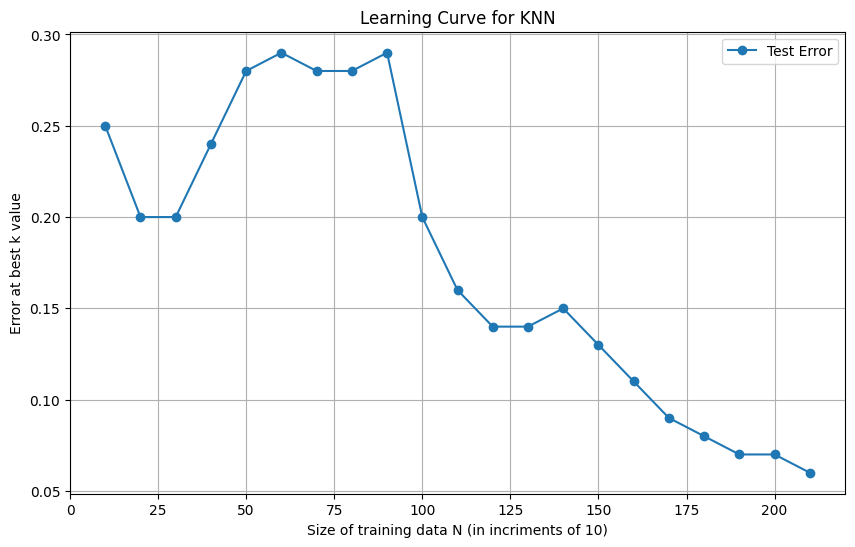

In [16]:
#to plot learning curve, need N as a function of error. So x axis is N and y axis is error at best k
plt.figure(figsize=(10, 6))
plt.plot(N_vals, best_test_errors, marker = 'o', label = 'Test Error')
plt.xlabel("Size of training data N (in incriments of 10)")
plt.ylabel("Error at best k value")
plt.title('Learning Curve for KNN')
plt.grid(True)
plt.legend()
plt.show()

Analysis of Learning curve


1.   The more training data you give KNN, the lower the error.
2.   at 210, KNN error for training size 210 is still declining. Have not plateu'd yet
3. Between N = 50 - 100, error doesnt change much until after 100, where error drops steadily.
4. At N = 20, start to increase in error, then plateu, then decrease
5. observation 3 and 4 indicate some instability. I think its cause at such small training data, not only is the learning unstable, but we are not using good enough k NN incriments. For example. At N=20, using k = {1, 6, 11, 16}. At N= 30 using k = {1, 6, 11, 16, 21, 26}. The best k is in somewhere in the middle, but with such small training data, its hard to define proper distinction. May skip over better intermediate k at that training data size.


Ran again by incrimenting +1 in k rather than just +5.

1. Learning curve didnt really change much since Im really just plotting training data vs error, so finding best k doing 1 k at a time doesnt change that reasoning.
2. the optimal k vs trainnig size plot (below) changed a lot. Basically, at N=10, we are now samplgin k = {1,2,3,4,5,6,7,8,9}, at N=20, k = {1,2,3,...,19} and so forth. Now that we have finer k results, can see that the trainig size increases, the best k's are getting larger. It plateus at N=80, k approx 41. So for a training size of 90, to get the best results, need to calculate the 41 NN which is redonkulous. at N=100, now only need to calc like k = 3 or 4 NN and get MUCH better results. I would bet that the KNN for this dataset needs at least N=100 samples to be able to actually make plausible predicitons.
3. based off of the original plots in the beginnign of the notebook, the a lot of the data was clustered, so I think the clustering was hard to see at N=90, and needed at least N=100 to understand that there is a mean with enough variablility to make accurate KNN predictions.



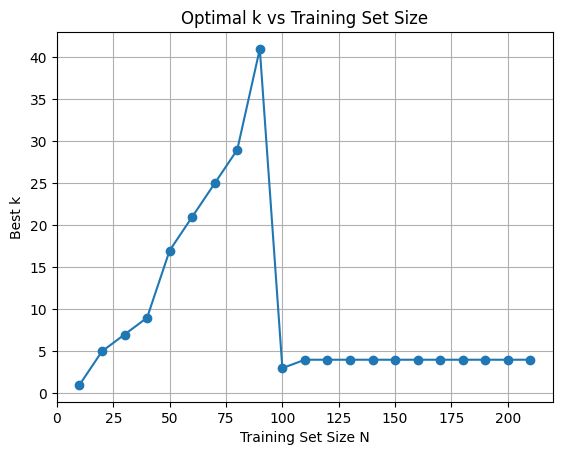

In [17]:
plt.plot(N_vals, best_k_vals, marker='o')
plt.xlabel('Training Set Size N')
plt.ylabel('Best k')
plt.title('Optimal k vs Training Set Size')
plt.grid(True)
plt.show()

#7(d)iA. replace eucledian distance with different distances
Since we saw that N = 210 was the best performing, let us use N=210 and select best k  when k incriments by one.

#What is Manhattan distance?
Manhattan distance is the following:
$$d(x,y) = \sum_{i=1}^n |x_i-y_i|$$
The eucledian distance between 2 points is a straight line. The mahattan distance between 2 points is a straight line in the x direction, followed by a straight line in the y direction. Called the "Manhattan" distance since it is the distance between two points if you were following a grid like structure like the streets of New York. Instead of going straight to a point and crossing buildings, you take a street in one direction, and a street in another perpendicular direction to arrive at the same point.

WRT to this data, the manhattan distance takes a patient data $A = (x_1, x_2, ..., x_6)$ and patient data $B = (y_1, y_2, ..., y_6)$ and finds the distance $d(A,B) = |x_1-y_1| + |x_2-y_2|+...+|x_6-y_6|$. This just finds the smallest distance between each feature and minimizes this distnace. This metric is equvalent to saying feature 1 of my test point matches which training point from all the trainig data, which feature 2 of my test point matches which training point of all test data, ..., then suimming them all together. The most pureset form of NN classification. If each individual feature is minimized, then the patient closest to me based off of that distance has GOT to be the most similar.

In [18]:
##lets recreate the workflow

#initalize variables. HW says select best k when k = {1, 6, 11, ..., 196}. This means N = 197. Idk why we dont use the 210
N = 197
ks = np.arange(1,N,5)

#get all training data. class 0 is 1st 70 of class 0. class1 is 1st 140 of class 1.
train0_210 = class0.iloc[:70]
train1_210 = class1.iloc[:140]

#combine training data
train_210 = pd.concat([train0_210, train1_210])

#split into x (data) and y (label)
x_train_210 = train_210.drop('class', axis =1) #data
y_train_210 = train_210['class']               #labels

#initalize testing data (I know I did this already, but more practice doesnt hurt).
test0 = class0.iloc[70:] #testing data for class 0 is the rest, which is patient 70 and above
test1 = class1.iloc[140:] #testing data for class 1 is the rest, which is patient 140 and above
test_210 = pd.concat([test0, test1]) #combine test data

#split into x (data) and y (label)
x_test_210 = test_210.drop('class', axis=1) #data
y_test_210 = test_210['class'] #labels


#initalize best k array
best_k_manhattan = None
min_error_manhattan = np.inf
#start looping through ks
for k in ks:
  #recreate model
  knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=1) #manhattan distance
  knn.fit(x_train_210, y_train_210)
  y_pred_manhattan = knn.predict(x_test_210)

  #get error
  acc_test_manhattan = (y_pred_manhattan == y_test_210).mean()
  test_error_manhattan = 1- acc_test_manhattan

  #get best k
  if test_error_manhattan < min_error_manhattan:
    min_error_manhattan = test_error_manhattan
    best_k_manhattan = k

#store results
distance_results = []
distance_results.append({
    'Metric': 'Manhattan (k=parameter)',
    'Best parameter': best_k_manhattan,
    'Best Test Error': min_error_manhattan
})

print(distance_results)




[{'Metric': 'Manhattan (k=parameter)', 'Best parameter': np.int64(6), 'Best Test Error': np.float64(0.10999999999999999)}]


#What is minkowski distance of varying p?
It is:
$$d(x,y) = \left(\sum_{i=1}^n|x_i-y_i|^p\right)^{1/p}$$
At p = 2 is the eucledian distance in 2D. This is basically running through different distance measurements (sum of difference squared square root, sum of difference cubed to the 3rd root, ...). In general it takes the difference and applys some power to it and takes the 1/power root of it. For large p, penalizes diffrences heavier.

As $p⟶∞$, $d(x,y)$ approaches the Chebyshev distance which is:
$$d(x,y) = L_{\infty} = max_i|x_i-y_i|$$

In [19]:
#7(d)iB- manhattan distance but with log_10(p) in {0.1,0.2,...1}. use k* which is best k, which is 6 for me and find best p
best_man_k = best_k_manhattan

#initalize p values
logp_vals = np.arange(0.1, 1.1, 0.1)
p_vals = 10 ** logp_vals

best_p = None
min_p_error = np.inf

for p in p_vals:
  knn = KNeighborsClassifier(n_neighbors=best_man_k, metric='minkowski', p=p)
  knn.fit(x_train_210, y_train_210)
  y_pred_p = knn.predict(x_test_210)

  #get error
  acc_test_p = (y_pred_p == y_test_210).mean()
  test_error_p = 1- acc_test_p

  if test_error_p < min_p_error:
    min_p_error = test_error_p
    best_p = p

#store results
distance_results.append({
    'Metric': 'Minkowski (p=parameter)',
    'Best parameter': best_p,
    'Best Test Error': min_p_error,
})

distance_results



[{'Metric': 'Manhattan (k=parameter)',
  'Best parameter': np.int64(6),
  'Best Test Error': np.float64(0.10999999999999999)},
 {'Metric': 'Minkowski (p=parameter)',
  'Best parameter': np.float64(3.9810717055349722),
  'Best Test Error': np.float64(0.06000000000000005)}]

In [20]:
#chebyshev distance. Compute the distance in every point and KEEP the LARGEST one. This is basically the "worst" match.

best_k_chebyshev = None
min_error_chebyshev = np.inf

for k in ks:
  knn = KNeighborsClassifier(n_neighbors=k, metric='chebyshev')
  knn.fit(x_train_210, y_train_210)
  y_pred_chebyshev = knn.predict(x_test_210)
  acc_test_chebyshev = (y_pred_chebyshev == y_test_210).mean()
  test_error_chebyshev = 1- acc_test_chebyshev
  if test_error_chebyshev < min_error_chebyshev:
    min_error_chebyshev = test_error_chebyshev
    best_k_chebyshev = k

#store results
distance_results.append({
    'Metric': 'Chebyshev (k=parameter)',
    'Best parameter': best_k_chebyshev,
    'Best Test Error': min_error_chebyshev
})

distance_results

[{'Metric': 'Manhattan (k=parameter)',
  'Best parameter': np.int64(6),
  'Best Test Error': np.float64(0.10999999999999999)},
 {'Metric': 'Minkowski (p=parameter)',
  'Best parameter': np.float64(3.9810717055349722),
  'Best Test Error': np.float64(0.06000000000000005)},
 {'Metric': 'Chebyshev (k=parameter)',
  'Best parameter': np.int64(16),
  'Best Test Error': np.float64(0.07999999999999996)}]

# What is Mahalanobis Distance?
I remember this. Did this in EE569 for K means clustering.It basically meausres distance in the sense of statistics. Measures the distance in variation in data, i.e, if we want to minimize the Mahalanobis distance, which test data is statistically the most like the train data? Which train data point matches test point the most in terms of mean and standard deviation?

The distance is
$$d(x,y) = \sqrt{(x-y)^TS^{-1}(x-y)}$$
where $S$ is the covariance matrix of the training data.

In [21]:
#chebyshev distance. Compute the distance in every point and KEEP the LARGEST one. This is basically the "worst" match.



best_k_mahalanobis = None
min_error_mahalanobis = np.inf

#need to define covariance matrix so I can pass it into the metric. Need covariance matrix of the TRAINING data
cov_matrix = np.cov(x_train_210, rowvar = False) #this finds the standard deviation of itself (diagonals) and other test data (off-diagonals). I also took this from googling sklearn's KNearestNeighbors implementation
inv_cov = np.linalg.inv(cov_matrix) #inverse of the covariance matrix is needed for Mahalanobis metric

for k in ks:
  knn = KNeighborsClassifier(n_neighbors=k, metric='mahalanobis', metric_params={'VI': inv_cov})
  knn.fit(x_train_210, y_train_210)
  y_pred_mahalanobis = knn.predict(x_test_210)

  acc_test_mahalanobis = (y_pred_mahalanobis == y_test_210).mean()
  test_error_mahalanobis = 1- acc_test_mahalanobis

  if test_error_mahalanobis < min_error_mahalanobis:
    min_error_mahalanobis = test_error_mahalanobis
    best_k_mahalanobis = k


#store results
distance_results.append({
  'Metric': 'Mahalanobis (k=parameter)',
  'Best parameter': best_k_mahalanobis,
  'Best Test Error': min_error_mahalanobis
})

distance_results

[{'Metric': 'Manhattan (k=parameter)',
  'Best parameter': np.int64(6),
  'Best Test Error': np.float64(0.10999999999999999)},
 {'Metric': 'Minkowski (p=parameter)',
  'Best parameter': np.float64(3.9810717055349722),
  'Best Test Error': np.float64(0.06000000000000005)},
 {'Metric': 'Chebyshev (k=parameter)',
  'Best parameter': np.int64(16),
  'Best Test Error': np.float64(0.07999999999999996)},
 {'Metric': 'Mahalanobis (k=parameter)',
  'Best parameter': np.int64(1),
  'Best Test Error': np.float64(0.17000000000000004)}]

In [22]:
#create table of results
distance_table = pd.DataFrame(distance_results)
distance_table = distance_table.round(3)
distance_table

,Metric,Best parameter,Best Test Error
0,Manhattan (k=parameter),6.000,0.11
1,Minkowski (p=parameter),3.981,0.06
2,Chebyshev (k=parameter),16.000,0.08
3,Mahalanobis (k=parameter),1.000,0.17


#7e:The majority polling decision can be replaced by weighted decision, in which the weight of each point in voting is inversely proportional to its distance from the query/test data point. In this case, closer neighbors of a query point will havea greater influence than neighbors which are further away. Use weighted voting with Euclidean, Manhattan, and Chebyshev distances and report the best testerrors when k ∈ {1, 6, 11, 16, . . . , 196}. (10 pts)'


In [23]:
#use same parameters as before, pretty much do the same thing as above but using weights = 'distance' in the KNN classifier

#store another table
test_err_table_weight = []

In [24]:
#Manhattan distance

best_k_manhattan_weight = None
min_error_manhattan_weight= np.inf

ks_weight = np.arange(1, 197, 5) #HW wants ks to start at 1, then end at 196, incrementing by 5

for k in ks_weight:
  knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=1, weights='distance')
  knn.fit(x_train_210, y_train_210)
  y_pred_manhattan_weight = knn.predict(x_test_210)


  acc_test_manhattan_weight = (y_pred_manhattan_weight == y_test_210).mean() #use test labeling to score results
  test_error_manhattan_weight = 1 - acc_test_manhattan_weight

  if test_error_manhattan_weight < min_error_manhattan_weight:
    min_error_manhattan_weight = test_error_manhattan_weight
    best_k_manhattan_weight = k


#store results
test_err_table_weight.append({
    'Metric': 'Manhattan (p=1)',
    'Best k': best_k_manhattan_weight,
    'Test Err at best k': min_error_manhattan_weight
})

In [25]:
test_err_table_weight

[{'Metric': 'Manhattan (p=1)',
  'Best k': np.int64(26),
  'Test Err at best k': np.float64(0.09999999999999998)}]

In [26]:
#Now do Euclediean distance



best_k_euclidean_weight = None
min_error_euclidean_weight= np.inf

ks_weight = np.arange(1, 197, 5) #HW wants ks to start at 1, then end at 196, incrementing by 5

for k in ks_weight:
  knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2, weights='distance') #default is eucledian, but will specificy minkowski with p=2 which is same thing using formula above.
  knn.fit(x_train_210, y_train_210)
  y_pred_euclidean_weight = knn.predict(x_test_210)


  acc_test_euclidean_weight = (y_pred_euclidean_weight == y_test_210).mean() #use test labeling to score results
  test_error_euclidean_weight = 1 - acc_test_euclidean_weight

  if test_error_euclidean_weight < min_error_euclidean_weight:
    min_error_euclidean_weight = test_error_euclidean_weight
    best_k_euclidean_weight = k


#store results
test_err_table_weight.append({
    'Metric': 'Euclidean (p=2)',
    'Best k': best_k_euclidean_weight,
    'Test Err at best k': min_error_euclidean_weight
})

In [27]:
test_err_table_weight

[{'Metric': 'Manhattan (p=1)',
  'Best k': np.int64(26),
  'Test Err at best k': np.float64(0.09999999999999998)},
 {'Metric': 'Euclidean (p=2)',
  'Best k': np.int64(6),
  'Test Err at best k': np.float64(0.09999999999999998)}]

In [28]:
#Now do Chebyshev distance

best_k_chebyshev_weight = None
min_error_chebyshev_weight= np.inf

ks_weight = np.arange(1, 197, 5) #HW wants ks to start at 1, then end at 196, incrementing by 5

for k in ks_weight:
  knn = KNeighborsClassifier(n_neighbors=k, metric='chebyshev', weights='distance') #default is eucledian, but will specificy minkowski with p=2 which is same thing using formula above.
  knn.fit(x_train_210, y_train_210)
  y_pred_chebyshev_weight = knn.predict(x_test_210)


  acc_test_chebyshev_weight = (y_pred_chebyshev_weight == y_test_210).mean() #use test labeling to score results
  test_error_chebyshev_weight = 1 - acc_test_chebyshev_weight

  if test_error_chebyshev_weight < min_error_chebyshev_weight:
    min_error_chebyshev_weight = test_error_chebyshev_weight
    best_k_chebyshev_weight = k


#store results
test_err_table_weight.append({
    'Metric': 'Chebyshev (p=inf)',
    'Best k': best_k_chebyshev_weight,
    'Test Err at best k': min_error_chebyshev_weight
})

In [29]:
test_err_table_weight

[{'Metric': 'Manhattan (p=1)',
  'Best k': np.int64(26),
  'Test Err at best k': np.float64(0.09999999999999998)},
 {'Metric': 'Euclidean (p=2)',
  'Best k': np.int64(6),
  'Test Err at best k': np.float64(0.09999999999999998)},
 {'Metric': 'Chebyshev (p=inf)',
  'Best k': np.int64(16),
  'Test Err at best k': np.float64(0.10999999999999999)}]

In [30]:
display_weight_table = pd.DataFrame(test_err_table_weight)
display_weight_table = display_weight_table.round(3)
display_weight_table

,Metric,Best k,Test Err at best k
0,Manhattan (p=1),26,0.10
1,Euclidean (p=2),6,0.10
2,Chebyshev (p=inf),16,0.11


#7(f) What is the lowest training error rate you achieved in this homework? (5 pts)

Lowest training error was using K = 1 for the KNN for ANY distance metric. This is because you are using TRAINING data to test TRAINING data. This basically amounts to taking a test value (which is IN the training data), then looking at the trainig data to find its closest distance. This will find ITSELF, and report ITSELF as its NN and be scored using TRAINING labels which will ALWAYS be 100%. KNN with k=1 specifically acts as a look up table for getting training accuracy, so always going to get 100%. Model is memorizing, not learning.

If you did this with testing data, then there probably isnt an exact match, so not guaranteed 100%.

#Per lecture, plot best k using error from training and testing data


In [31]:
# Analysis for doing k plots.

k_vals = np.arange(1, 197, 5)

train_errors = []
test_errors = []

for k in k_vals:

    # train model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_210, y_train_210)

    # training phase. get error for training data
    y_pred_train = knn.predict(x_train_210)
    train_error = 1 - (y_pred_train == y_train_210).mean()

    # testing phase. get error for testing data
    y_pred_test = knn.predict(x_test_210)
    test_error = 1 - (y_pred_test == y_test_210).mean()

    # store for plots
    train_errors.append(train_error)
    test_errors.append(test_error)


# find best k from minimum test error
best_idx = np.argmin(test_errors)
best_k = k_vals[best_idx]
min_test_error = test_errors[best_idx]


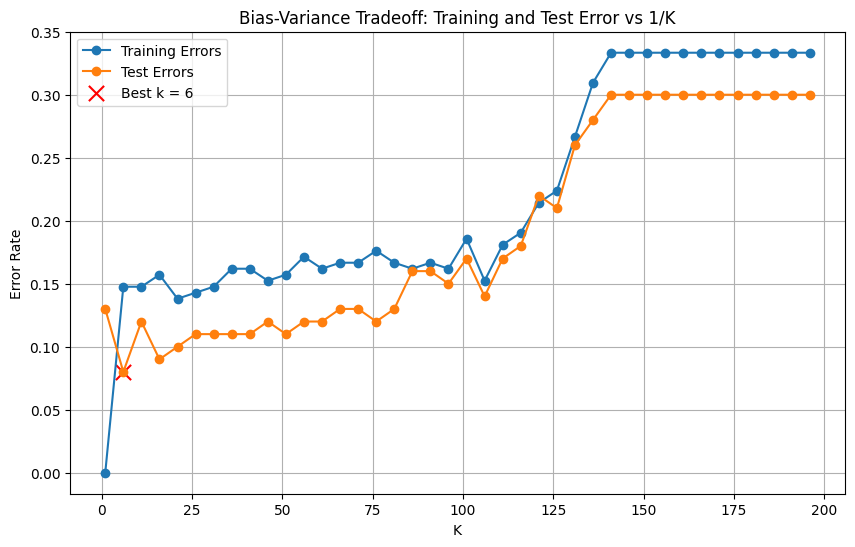

Best k = 6
Minimum test error = 0.07999999999999996


In [32]:
# plot
plt.figure(figsize=(10,6))

plt.plot(k_vals,train_errors,marker='o',label='Training Errors')

plt.plot(k_vals,test_errors,marker='o',label='Test Errors')

# mark best k
plt.scatter(best_k,min_test_error,color='red',s=120,marker='x',label=f'Best k = {best_k}')

plt.xlabel('K')
plt.ylabel('Error Rate')
plt.title('Bias-Variance Tradeoff: Training and Test Error vs 1/K')
plt.grid(True)
plt.legend()
plt.show()


print(f'Best k = {best_k}')
print(f'Minimum test error = {min_test_error}')



1.   See that training error is 0% at k=1, which we know is just "memorizing the data". This is what the lecture discussed.
2.   We see that error goes down as k increaes, then starts to do something weird, then see train error goes down while test error goes up. Thi si sthat trade off we are talking about
3.   See that "sweet spot" where training error begins to go down and test error begins to go up is at k=6, which matches the previous results. This tells us that we only need the 6 NN to be able to classify data accurately. The larger the k from there, the lower the testing data is because we are fitting noise (overfitting). The lower the k from the sweet spot, we are underfitting, and need more data to classify better.

